# GRA: lion

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:

Test these Lion extensions:

**relativistic**

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *

In [4]:
cfg = TrainConfig(dataset='CIFAR10', epochs=20, device="cuda:0", verbose=True, amp=False)

In [5]:
kws = dict(betas=(0.8, 0.99), use_curvature=False)

# name = f"Relativistic Lion — m={mass:0.3g}"

experiments = [
    Experiment(
        f"Relativistic Lion — lr={lr},mass={m}",
        make_opt(RelativisticLion, lr=lr, mass=m, **kws),
    ) for lr, m in itertools.product([1e-3], [100])
]

results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/20:  Train Loss 1.0094  |  Test Acc 76.31%

Epoch    2/20:  Train Loss 0.5769  |  Test Acc 82.48%

Epoch    3/20:  Train Loss 0.4164  |  Test Acc 83.39%

...

Epoch   17/20:  Train Loss 0.0380  |  Test Acc 87.88%

Epoch   18/20:  Train Loss 0.0369  |  Test Acc 87.87%

Epoch   19/20:  Train Loss 0.0330  |  Test Acc 88.09%

Epoch   20/20:  Train Loss 0.0295  |  Test Acc 87.73%

Finished in 68.6s

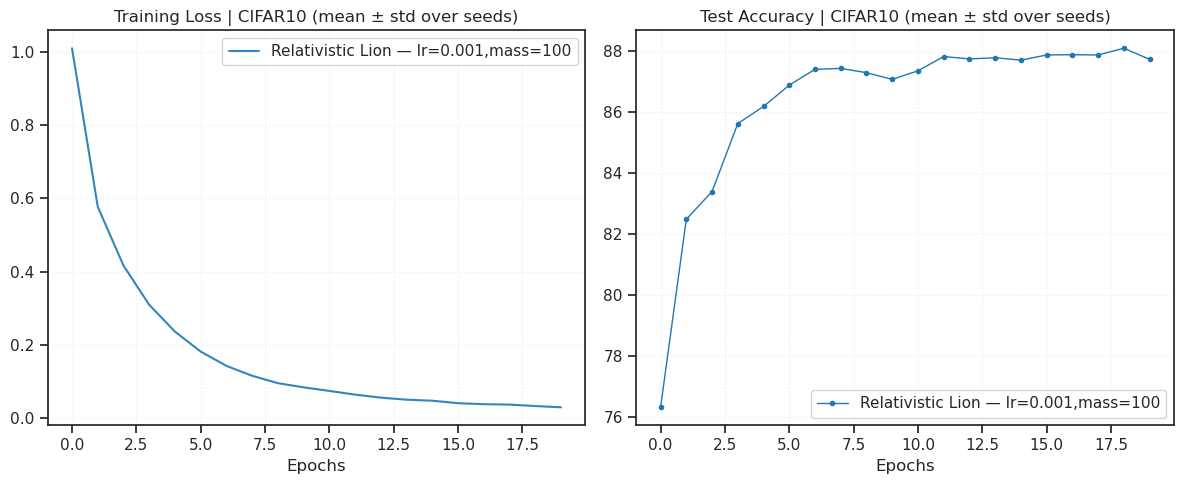

In [6]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

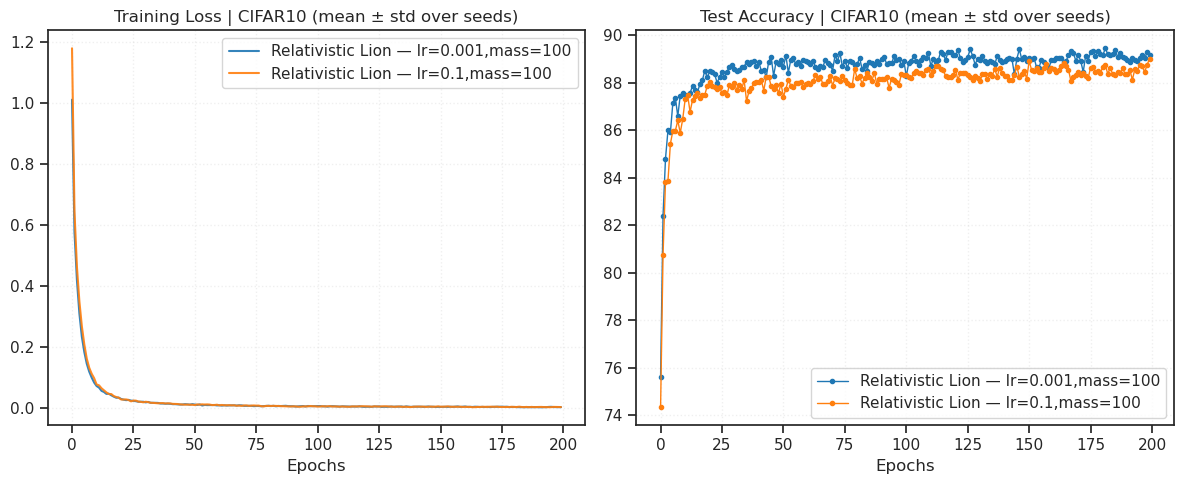

In [8]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [9]:
avg_scores = {k: np.round(d['test_acc'][-10:].mean(), decimals=1) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Lion — lr=0.1,mass=100': 88.0,
 'Relativistic Lion — lr=0.001,mass=100': 88.7}

In [7]:
## Were epochs=20 (why low? still a mystery)

{'Relativistic Lion — lr=0.1,mass=10': 10.0,
 'Relativistic Lion — lr=0.001,mass=10': 84.2,
 'Relativistic Lion — lr=0.1,mass=100': 85.7,
 'Relativistic Lion — lr=0.001,mass=100': 86.5}

In [12]:
## Was from the correct code (stat[p])

{'Relativistic Lion — lr=0.1,mass=10': 10.0,
 'Relativistic Lion — lr=0.01,mass=10': 76.9,
 'Relativistic Lion — lr=0.0001,mass=1000': 81.7,
 'Relativistic Lion — lr=0.1,mass=50': 82.3,
 'Relativistic Lion — lr=0.0001,mass=500': 82.7,
 'Relativistic Lion — lr=0.0001,mass=10': 83.2,
 'Relativistic Lion — lr=0.0001,mass=100': 83.2,
 'Relativistic Lion — lr=0.0001,mass=50': 83.3,
 'Relativistic Lion — lr=0.001,mass=1000': 83.5,
 'Relativistic Lion — lr=0.01,mass=1000': 83.6,
 'Relativistic Lion — lr=0.1,mass=1000': 83.8,
 'Relativistic Lion — lr=0.001,mass=10': 84.2,
 'Relativistic Lion — lr=0.01,mass=50': 84.3,
 'Relativistic Lion — lr=0.1,mass=500': 84.9,
 'Relativistic Lion — lr=0.001,mass=500': 85.0,
 'Relativistic Lion — lr=0.01,mass=500': 85.2,
 'Relativistic Lion — lr=0.01,mass=100': 85.7,
 'Relativistic Lion — lr=0.1,mass=100': 85.7,
 'Relativistic Lion — lr=0.001,mass=50': 86.2,
 'Relativistic Lion — lr=0.001,mass=100': 86.5}

In [8]:
print(ConvNet())

ConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): SiLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): SiLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (16): SiLU(inplace=True)
    (17): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): SiLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

## Test the effect of epochs

In [10]:
def _run(cfg):
    seed = 0
    
    scaler = torch.cuda.amp.GradScaler(
        enabled=bool(cfg.amp))

    if cfg.print_every is not None:
        print_every = cfg.print_every
    else:
        print_every = default_print_every(cfg.epochs)

    kws = dict(lr=1e-3, mass=100.0, betas=(0.8, 0.99) , use_curvature=False)
    opt_fn = make_opt(RelativisticLion, **kws)
    model = ConvNet().to(device)
    optim = opt_fn(model.parameters())
    criterion = torch.nn.CrossEntropyLoss()
    trn, vld = make_dataloader(cfg.dataset, device=device)

    train_loss = []
    test_acc = []

    start_time = time.time()

    for epoch in range(cfg.epochs):
        model.train()
        total_loss, n_batches = 0.0, 0

        for x, y in trn:
            x, y = x.to(device), y.to(device).long()

            optim.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=bool(cfg.amp)):
                out = model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()

            total_loss += float(loss.item())
            n_batches += 1

        avg_loss = total_loss / max(1, n_batches)
        train_loss.append(avg_loss)

        acc = evaluate_accuracy(model, vld)
        test_acc.append(acc)

        if cfg.verbose:
            should_print = (
                (epoch == 0) or
                (epoch + 1) == cfg.epochs or
                ((epoch + 1) % print_every == 0)
            )
            if should_print:
                print('  '.join([
                    f"Epoch {epoch+1:>4}/{cfg.epochs}:",
                    f"Train Loss {avg_loss:.4f}",
                    f"|  Test Acc {acc:.2f}%",
                ]))

    if cfg.verbose:
        print(f"Finished in {time.time() - start_time:.1f}s")

    results = {
        "train_loss": np.asarray(train_loss, dtype=np.float64),
        "test_acc": np.asarray(test_acc, dtype=np.float64),
    }
    return results

In [11]:
cfg_20 = TrainConfig(dataset='CIFAR10', epochs=20, device="cuda:0", verbose=True, amp=False)
cfg_200 = TrainConfig(dataset='CIFAR10', epochs=200, device="cuda:0", verbose=True, amp=False)

In [12]:
res_20 = _run(cfg_20)

Epoch    1/20:  Train Loss 1.0152  |  Test Acc 76.35%

Epoch    2/20:  Train Loss 0.5816  |  Test Acc 80.89%

Epoch    3/20:  Train Loss 0.4175  |  Test Acc 83.05%

Epoch    4/20:  Train Loss 0.3107  |  Test Acc 85.20%

Epoch    5/20:  Train Loss 0.2327  |  Test Acc 86.20%

...

Epoch   17/20:  Train Loss 0.0374  |  Test Acc 88.19%

Epoch   18/20:  Train Loss 0.0340  |  Test Acc 88.08%

Epoch   19/20:  Train Loss 0.0316  |  Test Acc 87.90%

Epoch   20/20:  Train Loss 0.0304  |  Test Acc 87.81%

Finished in 71.2s

In [13]:
res_200 = _run(cfg_200)

Epoch    1/200:  Train Loss 0.9962  |  Test Acc 77.07%

Epoch    5/200:  Train Loss 0.2321  |  Test Acc 86.75%

Epoch   10/200:  Train Loss 0.0810  |  Test Acc 87.27%

Epoch   15/200:  Train Loss 0.0453  |  Test Acc 88.05%

Epoch   20/200:  Train Loss 0.0307  |  Test Acc 88.44%

...

Epoch  185/200:  Train Loss 0.0018  |  Test Acc 89.16%

Epoch  190/200:  Train Loss 0.0022  |  Test Acc 89.25%

Epoch  195/200:  Train Loss 0.0027  |  Test Acc 89.24%

Epoch  200/200:  Train Loss 0.0030  |  Test Acc 88.93%

Finished in 619.6s

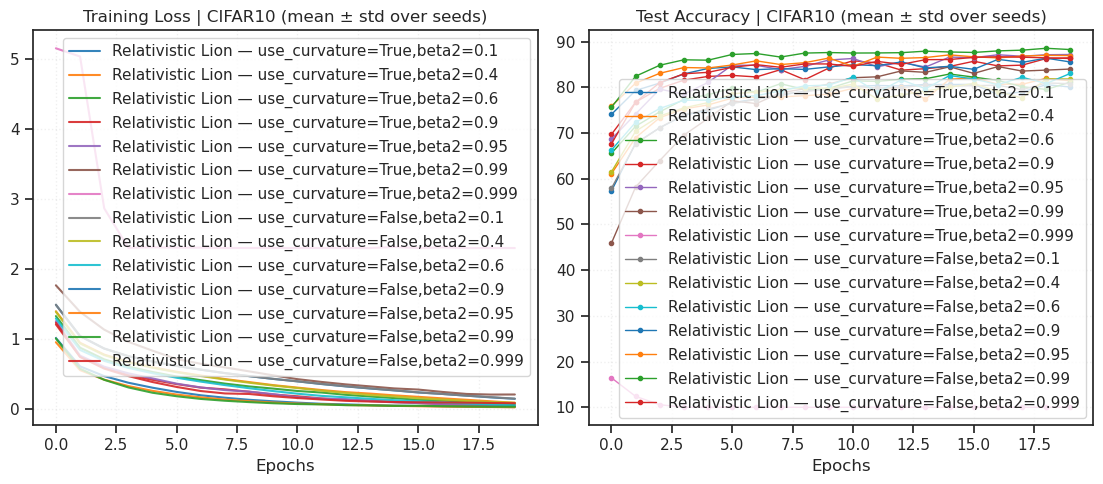

In [8]:
## Testing curvature and beta2

In [18]:
avg_scores = {k: np.round(d['test_acc'][-10:].mean(), decimals=1) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Lion — use_curvature=True,beta2=0.999': 10.5,
 'Relativistic Lion — use_curvature=True,beta2=0.1': 76.9,
 'Relativistic Lion — use_curvature=True,beta2=0.99': 76.9,
 'Relativistic Lion — use_curvature=False,beta2=0.1': 77.0,
 'Relativistic Lion — use_curvature=True,beta2=0.4': 77.5,
 'Relativistic Lion — use_curvature=False,beta2=0.4': 77.6,
 'Relativistic Lion — use_curvature=False,beta2=0.6': 78.9,
 'Relativistic Lion — use_curvature=True,beta2=0.6': 79.0,
 'Relativistic Lion — use_curvature=True,beta2=0.9': 82.8,
 'Relativistic Lion — use_curvature=True,beta2=0.95': 83.4,
 'Relativistic Lion — use_curvature=False,beta2=0.9': 83.7,
 'Relativistic Lion — use_curvature=False,beta2=0.999': 83.8,
 'Relativistic Lion — use_curvature=False,beta2=0.95': 85.0,
 'Relativistic Lion — use_curvature=False,beta2=0.99': 86.5}

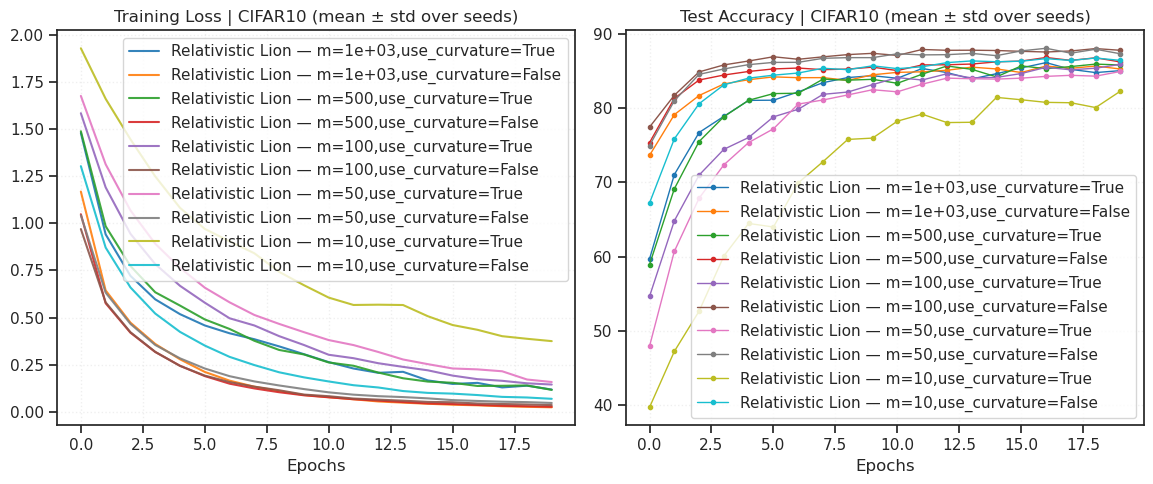

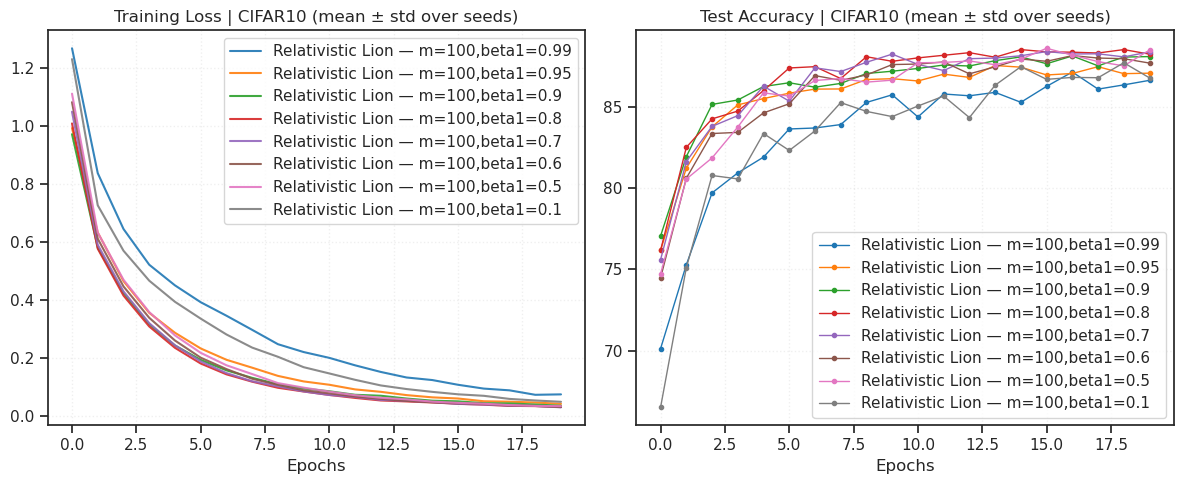

In [6]:
## Was testing for beta1